In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt

# cloelite imports: we load the following interfaces
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.cosmology.ReACTEmu_cosmology import MGemuNonlinearBoost, BoostedPerturbations

/opt/anaconda3/envs/mgemu_env/lib/python3.10/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
/opt/anaconda3/envs/mgemu_env/lib/python3.10/site-packages/MGEmu

 As it is the first instance of the emulator, we need to download some data, it can take a few seconds...




Downloading...
From: https://drive.google.com/uc?id=1LlGOP65E-7AND8SMAB3MUooxvvT9lHG8
To: /opt/anaconda3/envs/mgemu_env/lib/python3.10/site-packages/MGEmu/models_v4.zip
100%|███████████████████████████████████████████████████████████████████████████| 17.9M/17.9M [00:03<00:00, 4.65MB/s]

Download finished. Extracting files.
Done.



# Background quantities

In [6]:
zs = np.linspace(0, 3, 100)

# Baseline cosmology parameters
H0=70.0 
Omega_cdm0=0.25 
Omega_b0=0.05 
w0=-1 
wa=0 
Omega_k0 = 0.0 
ns = 0.96 
As = 2e-9
mnu = 0.06
N_mnu = 1

# Model of gravity or dark energy settings
# Which model? 
gravity_model = 'ide'

# Model parameters (fR0) 
fR0 = 1e-4

# Model parameters (DS) 
w0 = -0.9
wa = 0.1
xi = 30.

# Provide all expected keys, with harmless defaults for unused ones
mgpars = {
    "fr0": 0.0,
    "omega_rc": 0.0,   # only used for DGP
    "xi": xi,          # Used for all DS cases
    "gamma0": 0.55,    # only used for Linder gamma
    "q1": 0.0          # placeholder, adjust if needed
}

camb_instance = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, N_mnu=N_mnu, w0=w0, wa=wa, 
                               gamma_MG=0.0)


# Initialise background, linear perturbations and nonlinear LCDM spectrum 
linear_perturbations_camb = CAMBLinearPerturbations(camb_instance, zs)
nonlinear_perturbations_camb = CAMBNonLinearPerturbations(camb_instance, zs, nonlinear_model = 'mead2020')
nonlinear_perturbations_hmc = HMemuNonLinearPerturbations(camb_instance, linear_perturbations_camb, zs)

# Create the nonlinear MG boost
mg_boost = MGemuNonlinearBoost(camb_instance,linear_perturbations_camb, zs, gravity_model, mgpars, high_z_policy='one')
boost_interp = mg_boost.MGboost_interp

# Apply the nonlinear boost to HMCode and CAMB
boosted_perturbations_hmc = BoostedPerturbations(linear_perturbations_camb, nonlinear_perturbations_hmc, boost_interp)
boosted_perturbations_camb = BoostedPerturbations(linear_perturbations_camb, nonlinear_perturbations_camb, boost_interp)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


## Plot Powerspectra 

In [7]:
ks = np.logspace(np.log10(1e-4), np.log10(3), 100)
myz = [0,1]

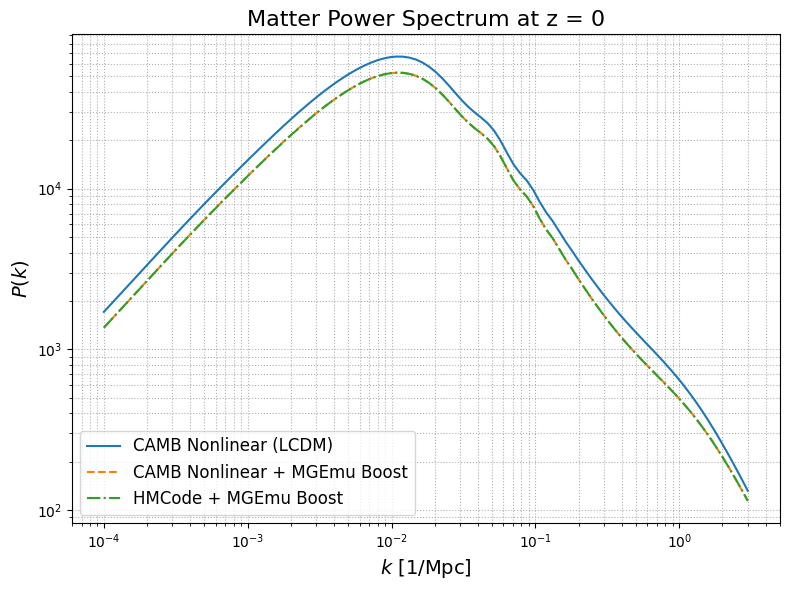

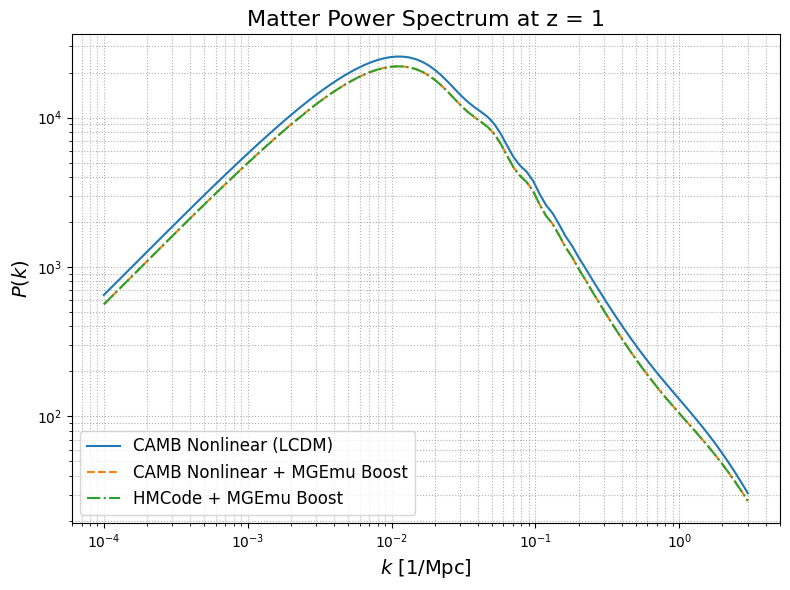

In [8]:
# Compute power spectra
nonlinear_pk_camb_lcdm = nonlinear_perturbations_camb.matter_power_spectrum(myz, ks)
nonlinear_pk_camb_mg = boosted_perturbations_camb.matter_power_spectrum(myz, ks)
nonlinear_pk_hmc_mg = boosted_perturbations_hmc.matter_power_spectrum(myz, ks)

# Plotting
for i, z in enumerate(myz):
    plt.figure(figsize=(8, 6))
    
    plt.loglog(ks, nonlinear_pk_camb_lcdm[i], label='CAMB Nonlinear (LCDM)', linestyle='solid')
    plt.loglog(ks, nonlinear_pk_camb_mg[i], label='CAMB Nonlinear + MGEmu Boost', linestyle='dashed')
    plt.loglog(ks, nonlinear_pk_hmc_mg[i], label='HMCode + MGEmu Boost', linestyle='dashdot')

    plt.xlabel(r'$k$ [1/Mpc]', fontsize=14)
    plt.ylabel(r'$P(k)$', fontsize=14)
    plt.title(f'Matter Power Spectrum at z = {z}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    plt.show()

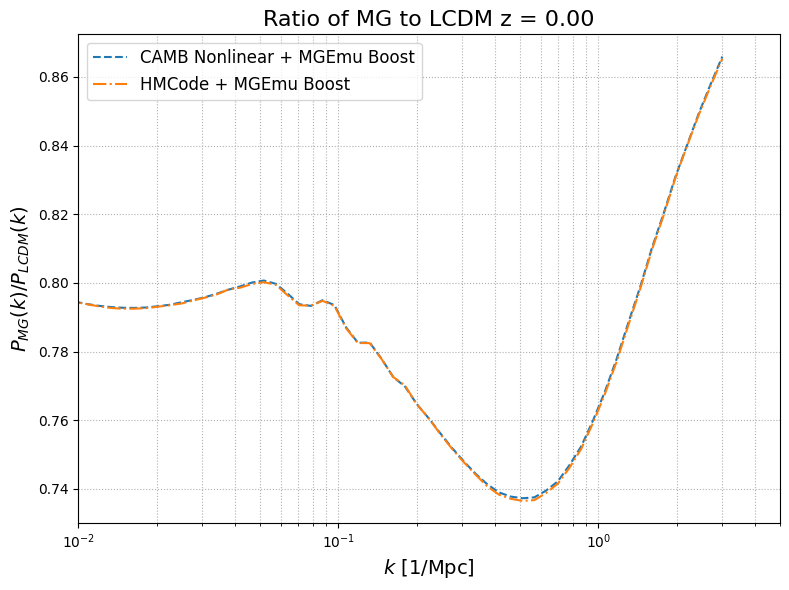

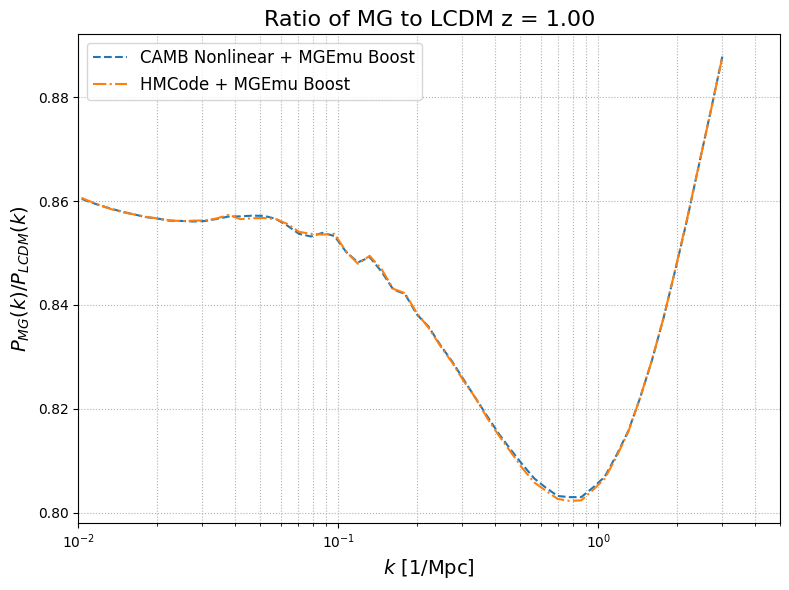

In [9]:
for i, z in enumerate(myz):
    plt.figure(figsize=(8, 6))
    plt.semilogx(ks, nonlinear_pk_camb_mg[i]/nonlinear_pk_camb_lcdm[i], label='CAMB Nonlinear + MGEmu Boost', linestyle='dashed')
    plt.semilogx(ks, nonlinear_pk_hmc_mg[i]/nonlinear_pk_camb_lcdm[i], label='HMCode + MGEmu Boost', linestyle='dashdot')

    plt.xlabel(r'$k$ [1/Mpc]', fontsize=14)
    plt.ylabel(r'$P_{MG}(k)/P_{LCDM}(k)$', fontsize=14)
    plt.xlim(1e-2, 5)
    plt.title(f'Ratio of MG to LCDM z = {z:.2f}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    plt.show()

# Test extrapolation 

In [10]:
ks_ex = np.logspace(np.log10(1e-4), np.log10(10), 200)
myz_ex = [0,2,30]

In [11]:
# Compute power spectra
nonlinear_pk_camb_lcdm_ex = nonlinear_perturbations_camb.matter_power_spectrum(myz_ex, ks_ex)
nonlinear_pk_camb_mg_ex = boosted_perturbations_camb.matter_power_spectrum(myz_ex, ks_ex)
nonlinear_pk_hmc_mg_ex = boosted_perturbations_hmc.matter_power_spectrum(myz_ex, ks_ex)


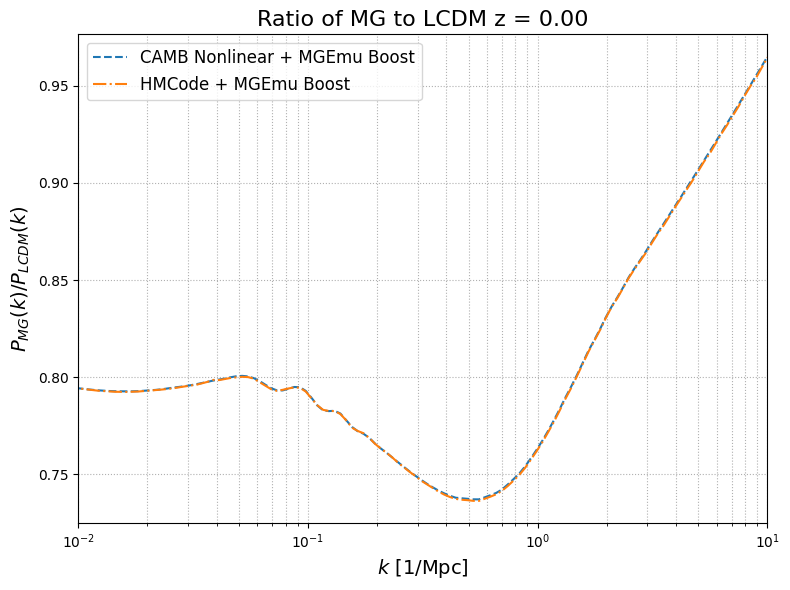

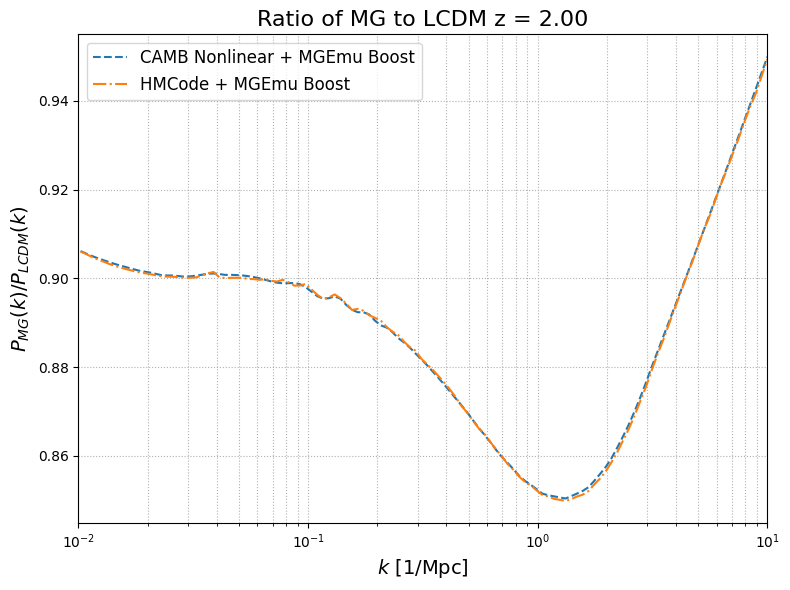

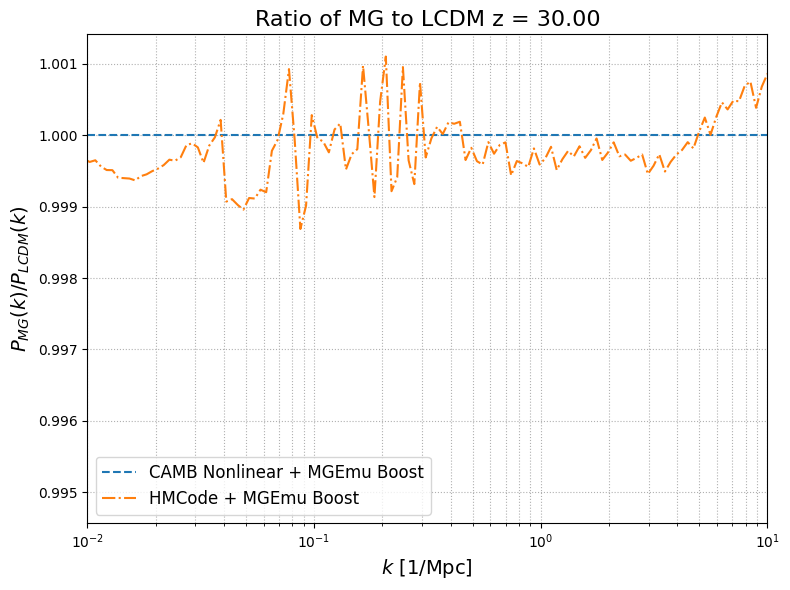

In [12]:
for i, z in enumerate(myz_ex):
    plt.figure(figsize=(8, 6))
    plt.semilogx(ks_ex, nonlinear_pk_camb_mg_ex[i]/nonlinear_pk_camb_lcdm_ex[i], label='CAMB Nonlinear + MGEmu Boost', linestyle='dashed')
    plt.semilogx(ks_ex, nonlinear_pk_hmc_mg_ex[i]/nonlinear_pk_camb_lcdm_ex[i], label='HMCode + MGEmu Boost', linestyle='dashdot')

    plt.xlabel(r'$k$ [1/Mpc]', fontsize=14)
    plt.ylabel(r'$P_{MG}(k)/P_{LCDM}(k)$', fontsize=14)
    plt.xlim(1e-2, 10)
    plt.title(f'Ratio of MG to LCDM z = {z:.2f}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    plt.show()